# 🐧 Palmer Penguins: Morphological Analysis & Species Prediction

## Project Overview

This project explores the famous **Palmer Penguins dataset** to understand how penguin species differ in terms of morphology, habitat distribution, and sex-based characteristics.

The main goal is to identify the strongest numerical and categorical patterns that separate the three species:

- Adelie
- Chinstrap
- Gentoo

Beyond exploratory data analysis, this project also aims to build a simple machine learning classification model capable of predicting a penguin’s species based on its physical characteristics.

---

## Objectives

This notebook aims to answer the following questions:

1. How are penguin species distributed across different islands?
2. Which physical measurements best distinguish each species?
3. Are there meaningful differences between male and female penguins?
4. What numerical features are most strongly correlated?
5. Can we predict whether a penguin is an **Adelie**, **Chinstrap**, or **Gentoo** based on its measurements?

---

## Final Goal

By the end of this analysis, the notebook will combine:

- Exploratory Data Analysis;
- Statistical interpretation;
- Visual storytelling;
- Feature relationship analysis;
- A species classification model.

The final model should allow us to estimate a penguin species from inputs such as:

- culmen length;
- culmen depth;
- flipper length;
- body mass;
- sex;
- island.

In [2]:
# Importing the libraries:

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# 📊 Data Understanding

Before starting the analysis, it is important to understand the dataset structure, variable types, and overall data quality.

This section explores:

- dataset dimensions;
- numerical and categorical features;
- missing values;
- invalid or inconsistent entries;
- basic statistical summaries.

Understanding the dataset structure helps guide the cleaning process and supports more reliable exploratory and statistical analysis throughout the project.

In [3]:
# Global variables to use in the notebook

categorical_col = ['species', 'island', 'sex']
numerical_col = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
palette = ["#EF476F", "#FFD166", "#06D6A0", "#118AB2", "#073B4C"]
# palette = https://coolors.co/palette/ef476f-ffd166-06d6a0-118ab2-073b4c

In [4]:
df = pd.read_csv("./data/penguins_size.csv")
df.head(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
print(f"The dimensions of the dataset are{df.shape[0]} lines and {df.shape[1]} variables")

# Checking the numeric values of the dataset
display(df.describe())

# Checking the data type and nulls of the dataset
display(df.info())

The dimensions of the dataset are344 lines and 7 variables


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


None

In [6]:
# Checking evert NaN values in the dataset
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [7]:
# Two penguins have NaN values for all numeric (and sex) variables.
# Eight of them have only the sex null.
# And one of them have the sex as a string = "."
# On the cleaning section, I will explain what to do with them.

display(print(df[~df["sex"].isin(["FEMALE", "MALE"])]))

    species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
3    Adelie  Torgersen               NaN              NaN                NaN   
8    Adelie  Torgersen              34.1             18.1              193.0   
9    Adelie  Torgersen              42.0             20.2              190.0   
10   Adelie  Torgersen              37.8             17.1              186.0   
11   Adelie  Torgersen              37.8             17.3              180.0   
47   Adelie      Dream              37.5             18.9              179.0   
246  Gentoo     Biscoe              44.5             14.3              216.0   
286  Gentoo     Biscoe              46.2             14.4              214.0   
324  Gentoo     Biscoe              47.3             13.8              216.0   
336  Gentoo     Biscoe              44.5             15.7              217.0   
339  Gentoo     Biscoe               NaN              NaN                NaN   

     body_mass_g  sex  
3            Na

None

# 🧹 Data Cleaning

Raw datasets often contain missing values, inconsistent information, or invalid entries that can negatively affect the analysis. This one is no different.

This section focuses on identifying and handling data quality issues to ensure the dataset is reliable, consistent, and ready for exploratory analysis and machine learning applications.

In this case, we will clean the rows that have NaN or "." values for the penguin's sex.
Since these occurrences represent less than 5% of the dataset and could negatively affect statistical analysis and model performance, the affected rows were removed instead of being imputed.

In [8]:
# Creating a new dataframe with cleaner values

clean_df = df[
    df["sex"].notna() &
    (df["sex"] != ".")
].copy()

if clean_df.isna().sum().sum() == 0:
    print("Inconsistences removed")
else:
    print("There are still inconsistent")
clean_df

Inconsistences removed


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


# 🔍 Exploratory Data Analysis (EDA) and Data Visualization

Exploratory Data Analysis is used to investigate patterns, relationships, and behaviors within the dataset.

This section explores both numerical and categorical variables through statistical summaries and visual analysis, helping identify trends, distributions, correlations, and species-specific characteristics, the next cells will also display charts and graphical analysis to better understand penguin distributions, feature relationships, species separation, and potential behavioral patterns within the dataset.

In [9]:
# General frequency analysis for categorical variables

for col in categorical_col:
    print(clean_df[col].value_counts())
    print("-" * 40)

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64
----------------------------------------
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64
----------------------------------------
sex
MALE      168
FEMALE    165
Name: count, dtype: int64
----------------------------------------


C:\Users\leona\AppData\Local\Temp\ipykernel_22140\3587966155.py:13: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(
C:\Users\leona\AppData\Local\Temp\ipykernel_22140\3587966155.py:13: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(
C:\Users\leona\AppData\Local\Temp\ipykernel_22140\3587966155.py:13: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(


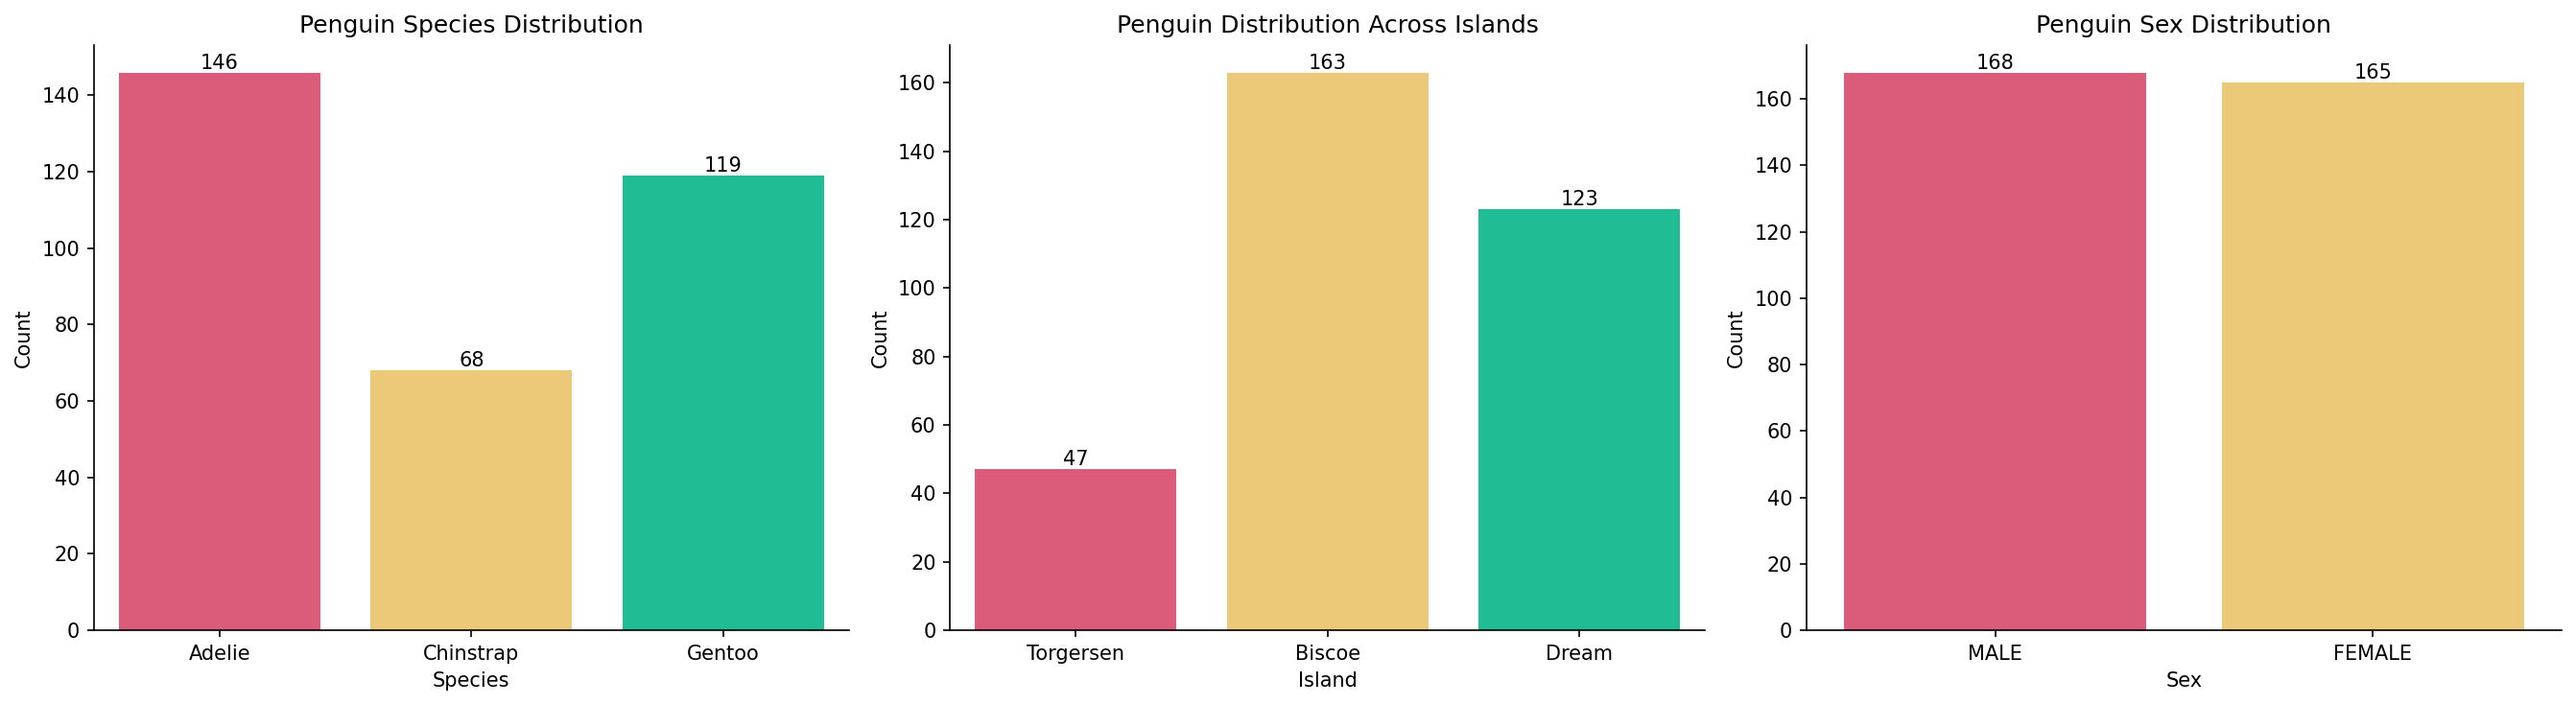

In [10]:
# Visualizing categorical variables

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

charts = [
    ("species", "Penguin Species Distribution", "Species"),
    ("island", "Penguin Distribution Across Islands", "Island"),
    ("sex", "Penguin Sex Distribution", "Sex")
]

for ax, (col, title, xlabel) in zip(axes, charts):

    sns.countplot(
        data=clean_df,
        x=col,
        hue=col,
        palette=palette,
        legend=False,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")

sns.despine()

plt.tight_layout()
plt.show()

In [11]:
# Mean numerical measurements by island and species

clean_df.groupby(["island", "species"])[numerical_col].mean().round(2)

culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
island    species                                                           
Biscoe    Adelie                38.98            18.37             188.80   
          Gentoo                47.57            15.00             217.24   
Dream     Adelie                38.52            18.24             189.93   
          Chinstrap             48.83            18.42             195.82   
Torgersen Adelie                39.04            18.45             191.53   

                     body_mass_g  
island    species                 
Biscoe    Adelie         3709.66  
          Gentoo         5092.44  
Dream     Adelie         3701.36  
          Chinstrap      3733.09  
Torgersen Adelie         3708.51

C:\Users\leona\AppData\Local\Temp\ipykernel_22140\61701797.py:4: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.countplot(


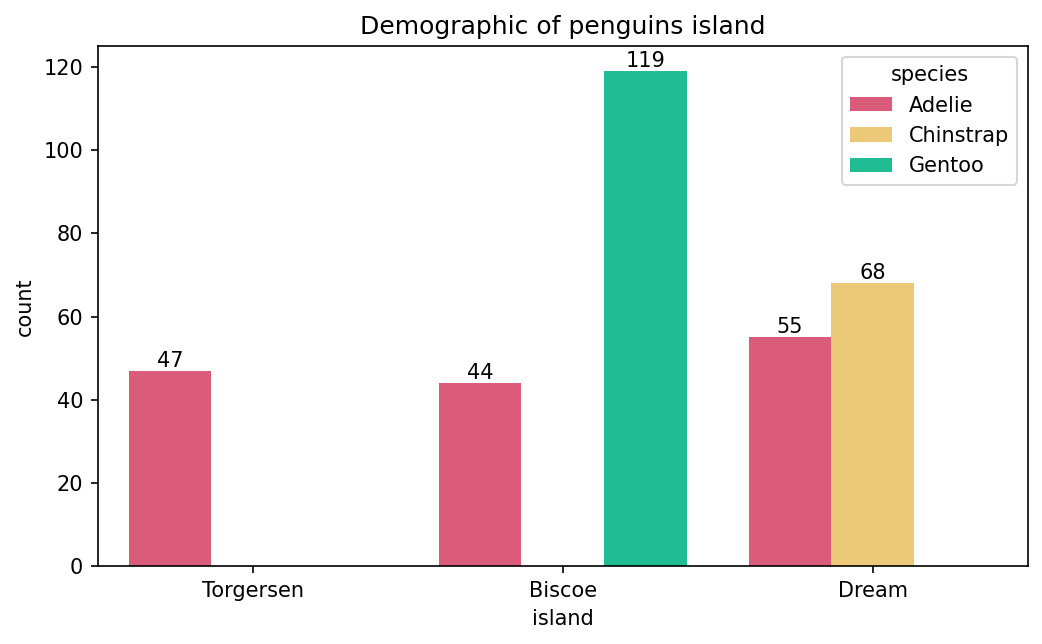

In [12]:
# Visualizing the data
plt.figure(figsize=(8, 4.5), dpi=150)

ax = sns.countplot(
    data=clean_df,
    x="island",
    hue="species",
    palette=palette,
    legend=True
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Demographic of penguins island")
plt.show()

In [13]:
# Checking numerical measurements by sex

clean_df.groupby(["species", "sex"])[numerical_col].mean().round(2)

# We can see that males, in all three species have more body mass, have
# larger culmen length and depth and a larger flipper.

culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
species   sex                                                            
Adelie    FEMALE             37.26            17.62             187.79   
          MALE               40.39            19.07             192.41   
Chinstrap FEMALE             46.57            17.59             191.74   
          MALE               51.09            19.25             199.91   
Gentoo    FEMALE             45.56            14.24             212.71   
          MALE               49.47            15.72             221.54   

                  body_mass_g  
species   sex                  
Adelie    FEMALE      3368.84  
          MALE        4043.49  
Chinstrap FEMALE      3527.21  
          MALE        3938.97  
Gentoo    FEMALE      4679.74  
          MALE        5484.84

C:\Users\leona\AppData\Local\Temp\ipykernel_22140\1235088606.py:5: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.histplot(


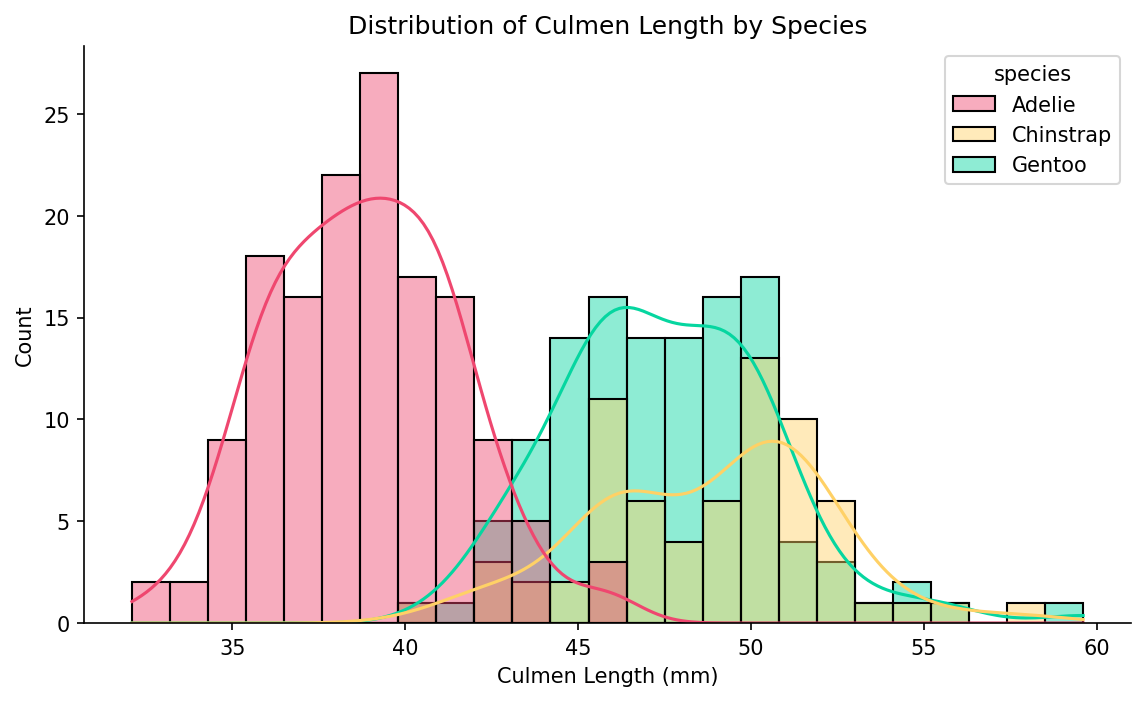

In [14]:
# Distribution of culmen length across penguin species

plt.figure(figsize=(9, 5), dpi=150)

sns.histplot(
    data=clean_df,
    x="culmen_length_mm",
    hue="species",
    kde=True,
    bins=25,
    palette=palette,
    alpha=0.45
)

plt.title("Distribution of Culmen Length by Species")
plt.xlabel("Culmen Length (mm)")
plt.ylabel("Count")

sns.despine()

plt.show()

# Checking for outliers

In [15]:
# Having a general view about the outliers

for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

# No outliers have been found.

culmen_length_mm: 0 outliers
culmen_depth_mm: 0 outliers
flipper_length_mm: 0 outliers
body_mass_g: 0 outliers


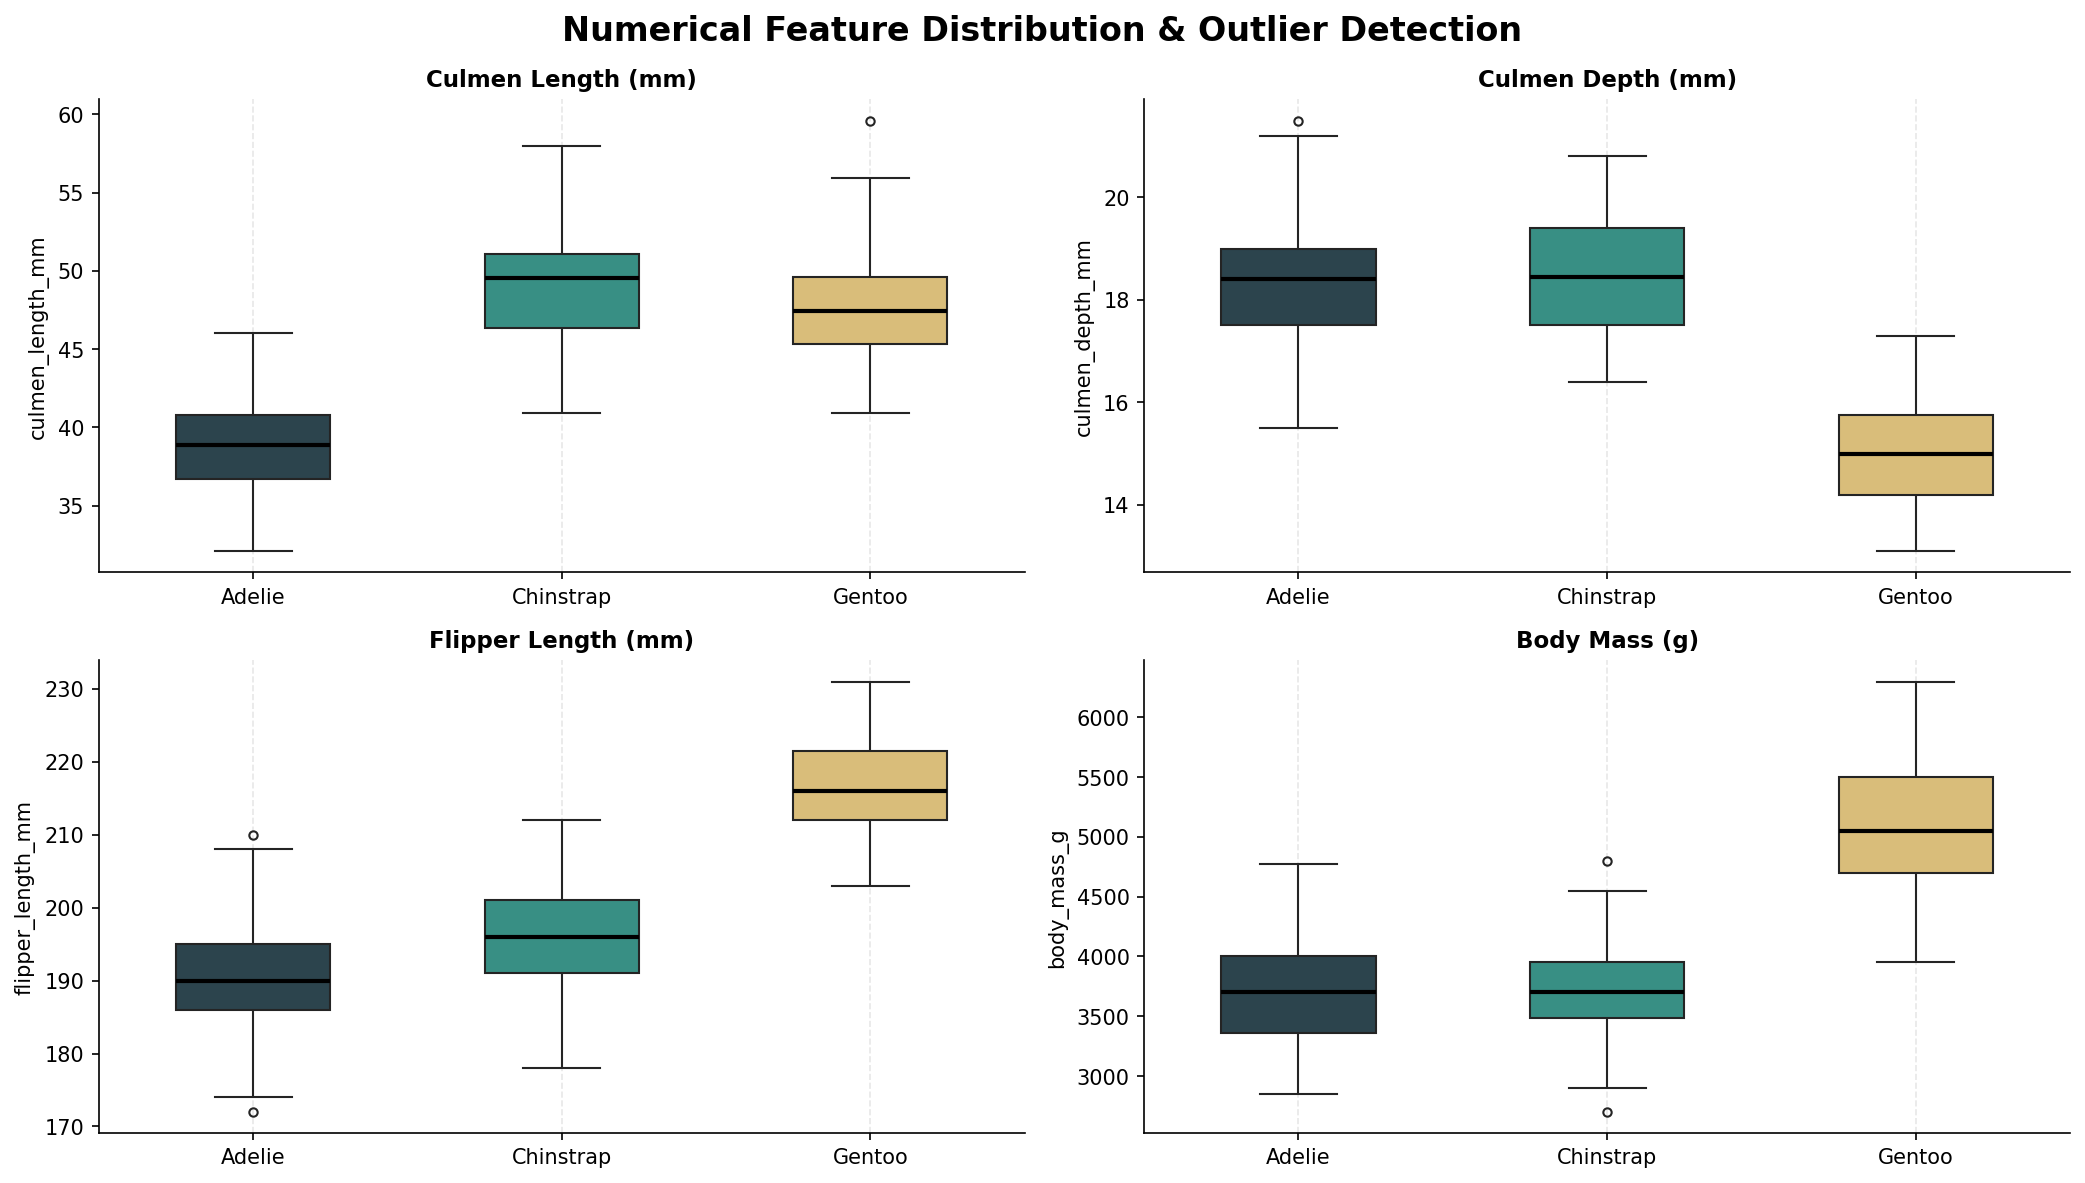

In [16]:
# Trying to investigate more about outliers. Now grouping by species

label_map = {
    "culmen_length_mm": "Culmen Length (mm)",
    "culmen_depth_mm": "Culmen Depth (mm)",
    "flipper_length_mm": "Flipper Length (mm)",
    "body_mass_g": "Body Mass (g)"
}

species_palette = {
    "Adelie": "#264653",
    "Chinstrap": "#2A9D8F",
    "Gentoo": "#E9C46A"
}

n_cols = len(numerical_col)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(14, 4 * n_rows),
    dpi=150
)

axes = axes.flatten()

for i, col in enumerate(numerical_col):

    sns.boxplot(
        data=clean_df,
        x="species",
        y=col,
        hue="species",
        ax=axes[i],
        palette=species_palette,
        width=0.5,
        fliersize=4,
        medianprops={"color": "black", "linewidth": 2}
    )

    axes[i].set_title(
        label_map[col],
        fontsize=11,
        fontweight="bold"
    )


    axes[i].set_xlabel("")
    axes[i].grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

for j in range(n_cols, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Numerical Feature Distribution & Outlier Detection",
    fontsize=16,
    fontweight="bold"
)

sns.despine()

plt.tight_layout()

plt.show()

In [17]:
# Detecting numerical outliers using the IQR method

for species in clean_df["species"].unique():

    print(f"\n{'=' * 60}")
    print(f"Species: {species}")
    print(f"{'=' * 60}")

    species_df = clean_df[clean_df["species"] == species]

    for col in numerical_col:

        Q1 = species_df[col].quantile(0.25)
        Q3 = species_df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = species_df[
            (species_df[col] < lower) |
            (species_df[col] > upper)
        ]

        print(f"\n{col}")
        print(f"Outliers detected: {len(outliers)}")


        if len(outliers) > 0:
            mean = species_df[col].mean()

            display(
                outliers[
                    [
                        "species",
                        "sex",
                        "island",
                        col
                    ]
                ]
            )

            print(f"Mean value: {mean:.2f}")

            for value in outliers[col]:

                percent_diff = (
                    (value - mean) / mean
                ) * 100

            print(
                f"Outlier value {value:.2f} "
                f"is {percent_diff:.2f}% "
                f"{'above' if percent_diff > 0 else 'below'} the average"
            )


Species: Adelie

culmen_length_mm
Outliers detected: 0

culmen_depth_mm
Outliers detected: 1


,species,sex,island,culmen_depth_mm
19,Adelie,MALE,Torgersen,21.5


Mean value: 18.35
Outlier value 21.50 is 17.18% above the average

flipper_length_mm
Outliers detected: 2


,species,sex,island,flipper_length_mm
28,Adelie,FEMALE,Biscoe,172.0
129,Adelie,MALE,Torgersen,210.0


Mean value: 190.10
Outlier value 210.00 is 10.47% above the average

body_mass_g
Outliers detected: 0

Species: Chinstrap

culmen_length_mm
Outliers detected: 0

culmen_depth_mm
Outliers detected: 0

flipper_length_mm
Outliers detected: 0

body_mass_g
Outliers detected: 2


,species,sex,island,body_mass_g
189,Chinstrap,MALE,Dream,4800.0
190,Chinstrap,FEMALE,Dream,2700.0


Mean value: 3733.09
Outlier value 2700.00 is -27.67% below the average

Species: Gentoo

culmen_length_mm
Outliers detected: 1


,species,sex,island,culmen_length_mm
253,Gentoo,MALE,Biscoe,59.6


Mean value: 47.57
Outlier value 59.60 is 25.29% above the average

culmen_depth_mm
Outliers detected: 0

flipper_length_mm
Outliers detected: 0

body_mass_g
Outliers detected: 0


### 🌍 Reviewing the outliers results

Here, I noticed that the detected outliers are not extreme or unrealistic, so the best approach is probably to simply leave them untreated.

A slightly chubbier penguin, a skinnier one, or even one with a somewhat larger flipper should not negatively affect the progression of the project.

However, if the dataset contained clearly unrealistic values — such as a penguin weighing -120g or another with a body mass of 50,000g — it would make sense to remove those observations from the dataset.

# 📐 Statistical Analysis

Statistical analysis helps validate patterns observed during exploratory analysis and provides a deeper understanding of feature relationships.

This section investigates correlations, group differences, and numerical behaviors across penguin species to support more reliable interpretations.

In [18]:
# First look at the correlations. Without a chart visualization.

for penguin_species in df['species'].dropna().unique():
    df_species = df[df['species'] == penguin_species].copy()
    print(f'Penguin species:{penguin_species}')
    print(df_species[numerical_col].corr().round(4))
    print('-' * 80)

Penguin species:Adelie
                   culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm             1.0000           0.3915             0.3258   
culmen_depth_mm              0.3915           1.0000             0.3076   
flipper_length_mm            0.3258           0.3076             1.0000   
body_mass_g                  0.5489           0.5761             0.4682   

                   body_mass_g  
culmen_length_mm        0.5489  
culmen_depth_mm         0.5761  
flipper_length_mm       0.4682  
body_mass_g             1.0000  
--------------------------------------------------------------------------------
Penguin species:Chinstrap
                   culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm             1.0000           0.6535             0.4716   
culmen_depth_mm              0.6535           1.0000             0.5801   
flipper_length_mm            0.4716           0.5801             1.0000   
body_mass_g                  

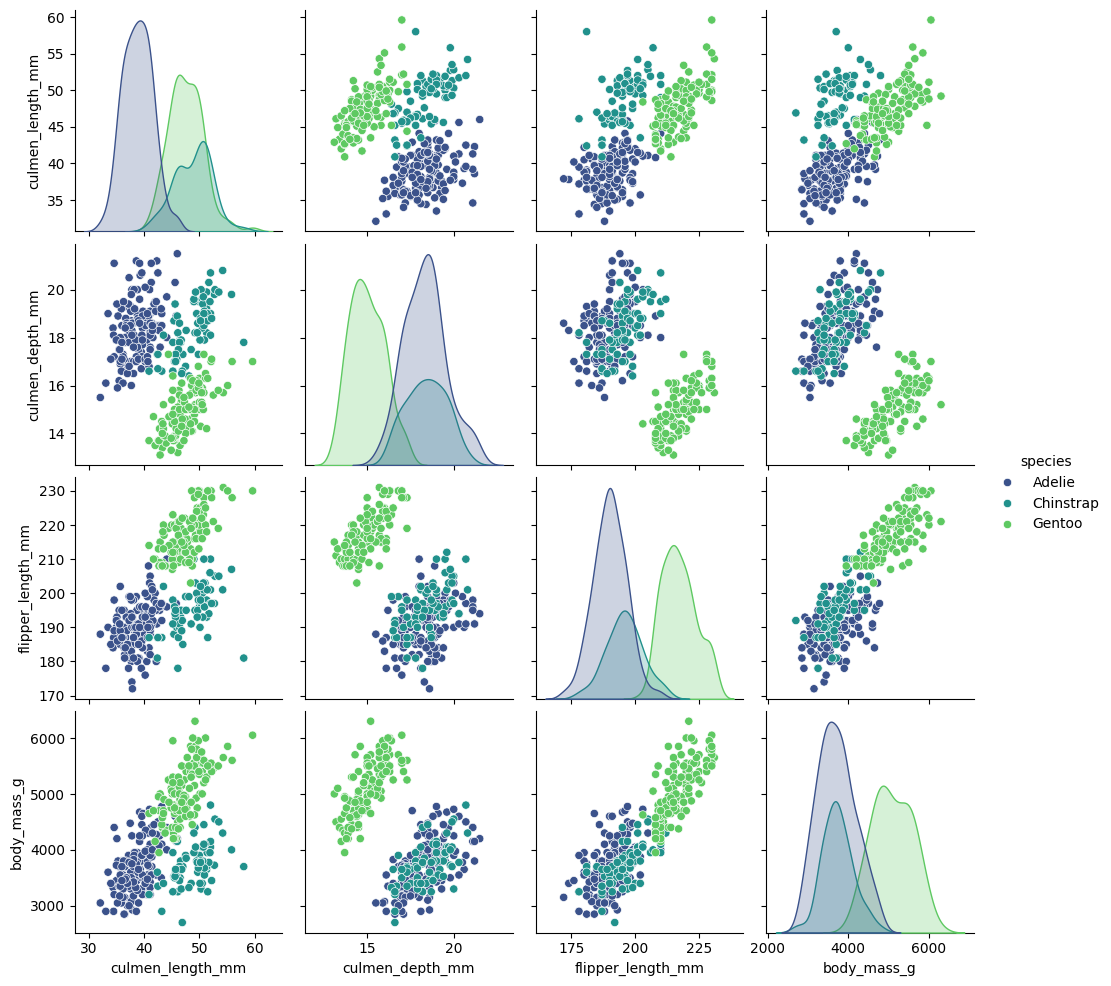

In [36]:
# Visualizing relationships, patterns and distributions across the numeric features. 

sns.pairplot(
    clean_df,
    hue="species",
    palette='viridis'
)

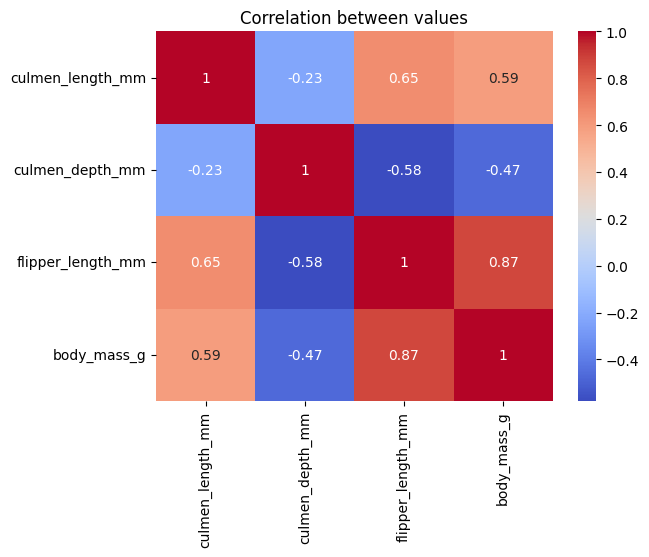

In [19]:
# Taking a look at a more generalistc correlation

corr_matrix = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

sns.heatmap(clean_df[corr_matrix].corr(), annot=True, cmap="coolwarm")
plt.title('Correlation between values')
plt.show()

In [20]:
print(clean_df["species"].unique().tolist())

['Adelie', 'Chinstrap', 'Gentoo']


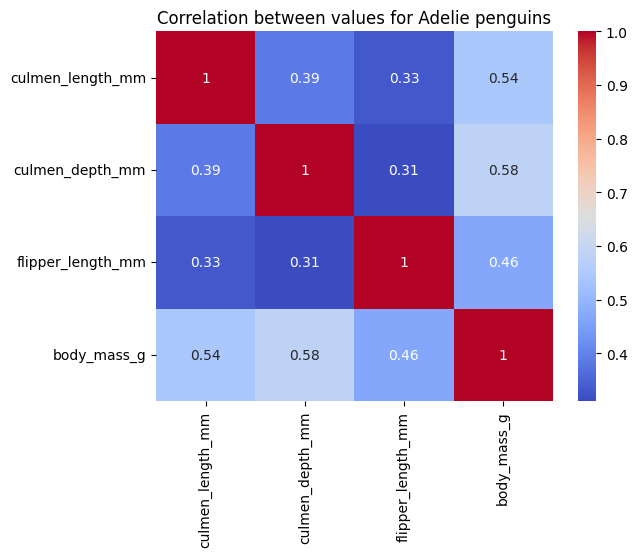

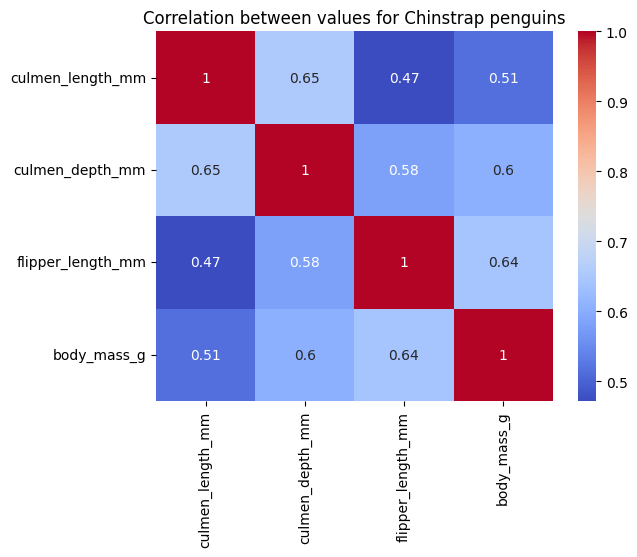

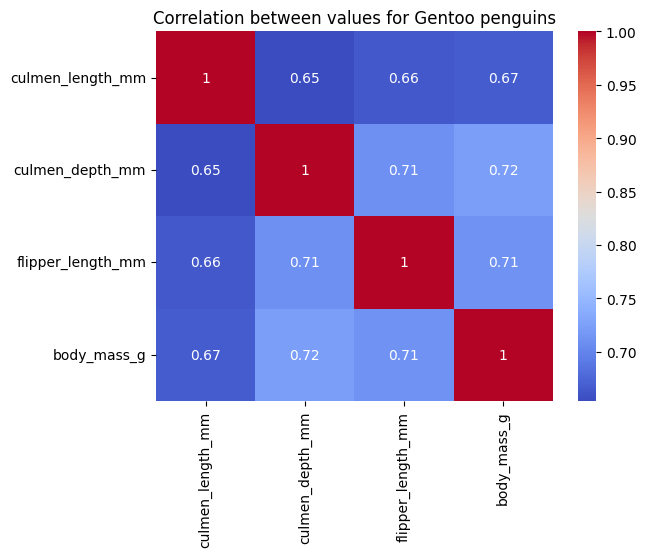

In [21]:
# Checking correlations with a different aspect, now grouping by species

corr_matrix = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

for specie in clean_df["species"].unique().tolist():
    specie_df = clean_df[clean_df["species"] == specie].copy()
    sns.heatmap(specie_df[corr_matrix].corr(), annot=True, cmap = 'coolwarm')
    plt.title(f'Correlation between values for {specie} penguins')
    plt.show()

In [22]:
# Display of the mean of each species attributes

df.groupby("species")[
    ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
].mean()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


C:\Users\leona\AppData\Local\Temp\ipykernel_22140\3439330783.py:11: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


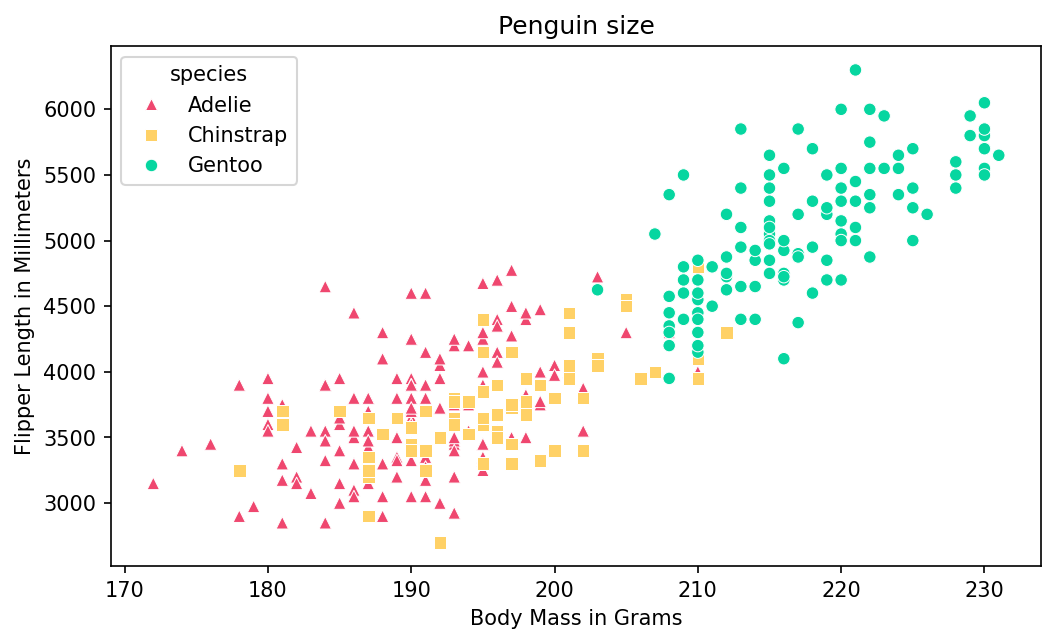

In [23]:
# Ploting a chart that displays penguins "size" grouping by penguins species

plt.figure(figsize=(8, 4.5), dpi=150)

markers = {
    "Adelie": "^",
    "Chinstrap": "s",
    "Gentoo": "o"
}

sns.scatterplot(
    data=df,
    y="body_mass_g",
    x="flipper_length_mm",
    hue="species",
    style="species",
    markers=markers,
    palette=palette
)

plt.title("Penguin size")
plt.xlabel("Body Mass in Grams")
plt.ylabel("Flipper Length in Millimeters")
plt.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_22140\662952521.py:12: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


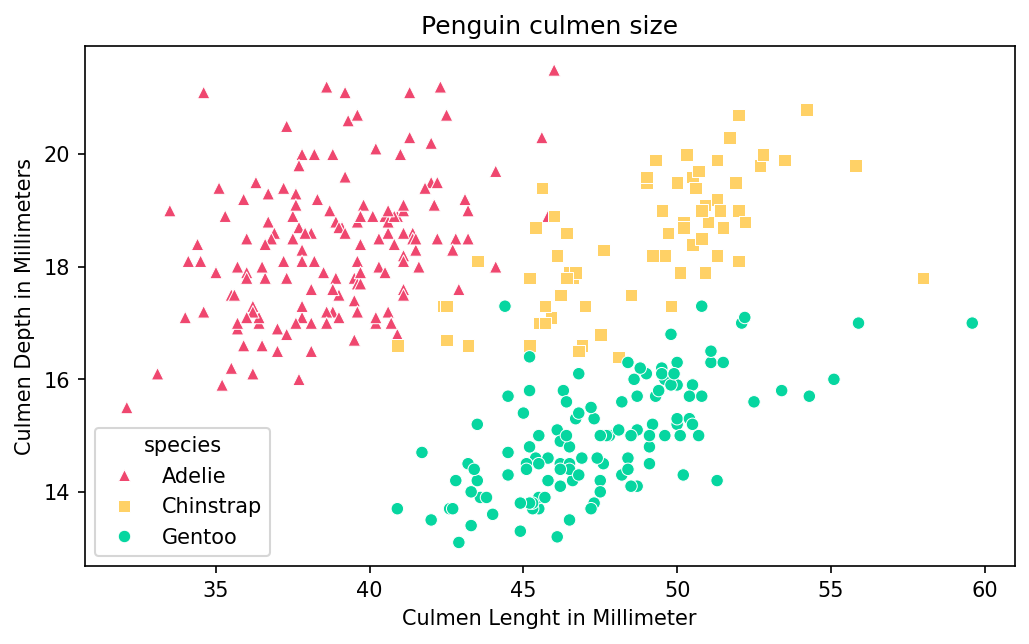

In [24]:
# Ploting a chart that displays penguins  "size" grouping by penguins species
# culmen_length_mm	culmen_depth_mm

plt.figure(figsize=(8, 4.5), dpi=150)

markers = {
    "Adelie": "^",
    "Chinstrap": "s",
    "Gentoo": "o"
}

sns.scatterplot(
    data=df,
    x="culmen_length_mm",
    y="culmen_depth_mm",
    hue="species",
    style="species",
    markers=markers,
    palette=palette
)

plt.title("Penguin culmen size")
plt.xlabel("Culmen Lenght in Millimeter")
plt.ylabel("Culmen Depth in Millimeters")
plt.show()

# 🤖 Machine Learning Modeling

After understanding and preparing the dataset, machine learning techniques can be applied to predict penguin species based on their physical characteristics.

This section focuses on building a classification model capable of identifying whether a penguin belongs to the Adelie, Chinstrap, or Gentoo species.

For this project, I choose the Random Forest Regressor and KNN models.

In [25]:
# Cleaning nominal features

# Creating dummies
rfr_df = pd.get_dummies(
    clean_df,
    columns=["sex", "island"],
    drop_first=True
)

encoder = LabelEncoder()
display(rfr_df.columns)
y = encoder.fit_transform(clean_df["species"])
# There is no need to normalization on this model, so we can proceed.

Index(['species', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex_MALE', 'island_Dream', 'island_Torgersen'],
      dtype='object')

In [26]:
# Random Forest Classifier

X = rfr_df.drop(columns="species")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

# 🧪 Model Evaluation

Model evaluation is essential to measure how well the machine learning model performs on unseen data.

This section analyzes prediction accuracy and classification performance to understand the strengths and limitations of the trained model.

Model's accuracy: 100.00%
Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

Confusion Matrix: 
[[29  0  0]
 [ 0 14  0]
 [ 0  0 24]]


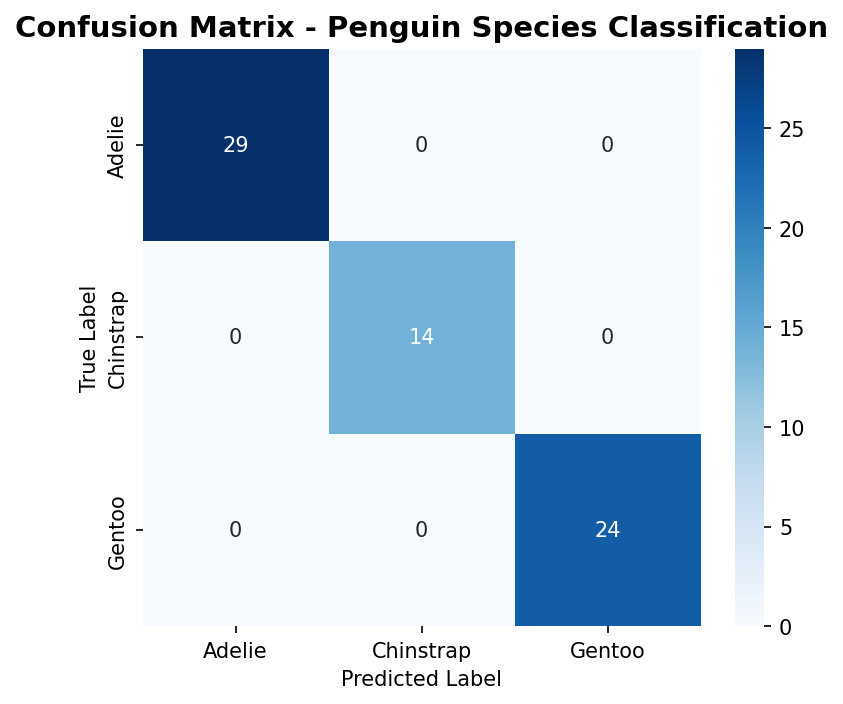

Train Accuracy: 100.00%
Test Accuracy: 100.00%


In [ ]:
print(f"Model's accuracy: {accuracy:.2%}")
print(f"Classification Report: ")
print(f"{classification_report(y_test, predictions)}")

# Confusion Matrix Heatmap

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5), dpi=150)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "Confusion Matrix - Penguin Species Classification",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()


print(f"Train Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy: {test_accuracy:.2%}")

In [28]:
new_penguin = pd.DataFrame([{
    "culmen_length_mm": 45.0,
    "culmen_depth_mm": 15.5,
    "flipper_length_mm": 220.0,
    "body_mass_g": 5000,
    "sex_MALE": 1,
    "island_Dream": 0,
    "island_Torgersen": 1
}])

new_penguin = new_penguin.reindex(columns=X.columns, fill_value=0)

predicted_species = model.predict(new_penguin)
decoded_species = encoder.inverse_transform(predicted_species)
prediction_proba = model.predict_proba(new_penguin)

print(f"Predicted species: {decoded_species[0]}")

print("\nPrediction probabilities:")
for species, probability in zip(encoder.classes_, prediction_proba[0]):
    print(f"{species}: {probability:.2%}")

Predicted species: Gentoo

Prediction probabilities:
Adelie: 20.00%
Chinstrap: 0.00%
Gentoo: 80.00%


### ⭐ Feature Importance

Now it's time to check the features importances. We can see that the model relied primarily on flipper length and body mass to distinguish penguin species.

This result aligns with the exploratory analysis, where Gentoo penguins demonstrated significantly larger body mass and flipper dimensions compared to the other species.

Geographical variables such as island also contributed to the predictions, although with lower importance. The same goes for gender variables.

In [29]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,culmen_length_mm,0.346468
2,flipper_length_mm,0.206044
1,culmen_depth_mm,0.202490
5,island_Dream,0.109648
3,body_mass_g,0.104252
6,island_Torgersen,0.024137
4,sex_MALE,0.006961


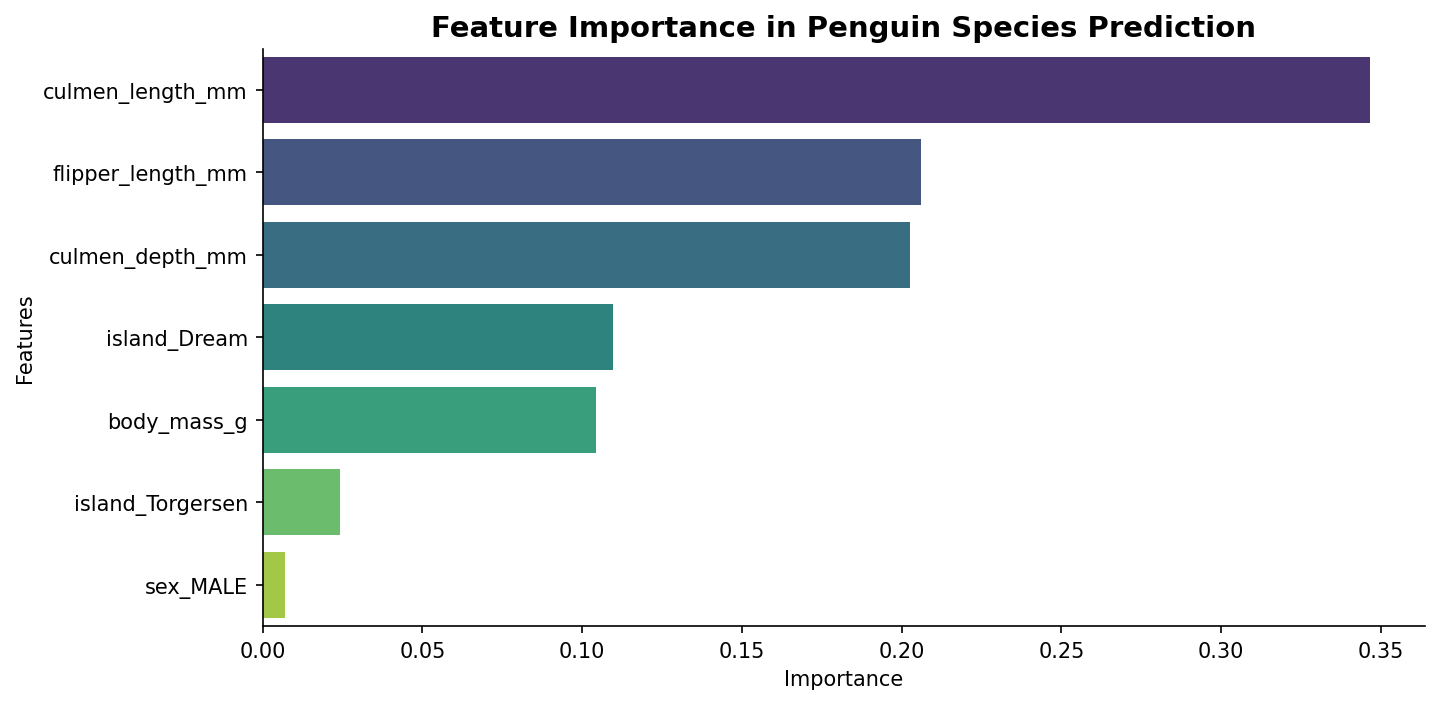

In [30]:
# Visualizing feature importance

plt.figure(figsize=(10, 5), dpi=150)

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Feature Importance in Penguin Species Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Features")

sns.despine()

plt.show()

# 🧠 Final Insights & Conclusion

The final section summarizes the most important findings discovered throughout the analysis.

Here, the main biological patterns, statistical relationships, visualization insights, and machine learning results are consolidated to provide a complete overview of the project outcomes.


## 🏝️ Islands and Species Distribution

Strong relationships were identified between penguin species and island distribution.

- **Adelie penguins** are the most geographically distributed species, being the only species present across all three islands.
- **Torgersen Island** is almost exclusively populated by Adelie penguins.
- **Biscoe Island** is strongly associated with Gentoo penguins.
- **Dream Island** is primarily inhabited by Chinstrap penguins.

Overall, island distribution alone already provides valuable predictive information for species classification:

- **Biscoe → Gentoo**
- **Dream → Chinstrap**
- **Torgersen → Adelie**

This suggests that habitat location plays an important role in distinguishing species across the Palmer Archipelago.

---

## 📊 Numerical Features & Morphological Patterns

Only a small number of statistical outliers were identified throughout the dataset. However, none of them appeared biologically unrealistic or extreme enough to justify removal.

The detected outliers most likely represent natural morphological variation between individual penguins rather than corrupted or inconsistent records.

### 🐧 Gentoo Penguins

- Gentoo penguins are significantly larger and heavier than the other species.
- They possess the highest average body mass and the largest flipper lengths in the dataset.
- Their culmen depth is noticeably smaller, giving them a sharper and more elongated beak appearance.
- Gentoo penguins also showed the strongest overall correlations between numerical variables.

One of the strongest relationships observed in the entire analysis was:

- **Body Mass × Culmen Depth → 0.72**
- **Body Mass × Flipper Length → 0.71**

This indicates that larger Gentoo penguins tend to consistently grow proportionally across multiple body measurements.

---

### 🐧 Adelie Penguins

- Adelie penguins are generally smaller and lighter compared to the other species.
- They possess the smallest culmen length and shorter flippers overall.
- Despite their smaller size, their culmen depth remains relatively high compared to Gentoo penguins.

Correlation analysis revealed weaker relationships between measurements for Adelie penguins compared to the other species.

For example:

- **Flipper Length × Culmen Depth → 0.31**
- **Flipper Length × Culmen Length → 0.33**

This suggests that Adelie penguins exhibit more independent variation between body features.

---

### 🐧 Chinstrap Penguins

- Chinstrap penguins are morphologically similar to Adelie penguins in terms of body mass.
- However, they possess noticeably larger and longer culmens, even surpassing Gentoo penguins in culmen length.
- Their flippers are slightly larger than Adelie penguins, placing them morphologically between Adelie and Gentoo.

Correlation patterns for Chinstrap penguins were moderate to strong across most measurements.

Notably:

- **Culmen Length × Culmen Depth → 0.65**
- **Flipper Length × Body Mass → 0.64**

This indicates a more proportionally consistent body growth pattern compared to Adelie penguins.

---

## 🔥 Correlation Analysis

Correlation analysis revealed clear differences in how body measurements interact across species.

- **Gentoo penguins** showed the strongest overall correlations, suggesting highly proportional body growth.
- **Adelie penguins** presented weaker correlations, indicating greater morphological variability between measurements.
- **Chinstrap penguins** occupied an intermediate position, with moderately strong relationships across most numerical features.

Among all variables, **body mass**, **flipper length**, and **culmen measurements** consistently demonstrated meaningful positive correlations across species.

---

## 🤖 Machine Learning Model

The Random Forest Classifier achieved extremely high predictive performance during testing.

The model successfully learned the morphological and geographical differences between species, reaching nearly perfect classification accuracy.

This high performance is likely related to:

- the strong separation between species;
- the relatively clean dataset;
- and the highly informative numerical features.

Additionally, the model was capable of predicting the species of hypothetical penguins based on custom user inputs such as:

- body mass;
- flipper length;
- culmen dimensions;
- sex;
- and island location.

This demonstrates that penguin species can be reliably inferred from a combination of physical and environmental characteristics.
